In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time setup
dt = 0.01
t = np.arange(0, 20*np.pi, dt)

In [4]:
def solve_oscillator(omega):
    x = 0
    v = 0

    xs = []

    for ti in t:
        a = np.cos(omega * ti) - x

        x += v * dt
        v += a * dt

        xs.append(x)

    return np.array(xs)
    

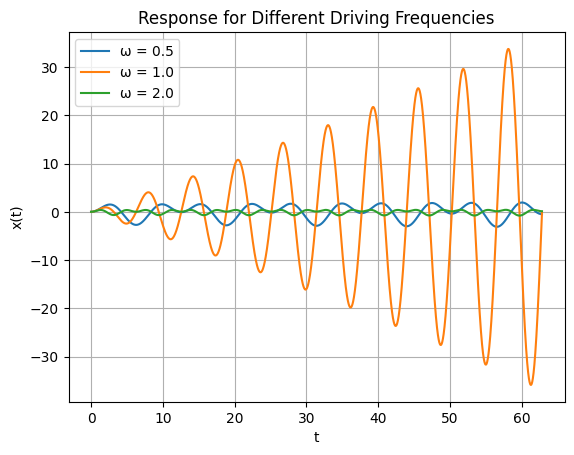

In [5]:
omegas = [0.5, 1.0, 2.0]

plt.figure()

for omega in omegas:
    x = solve_oscillator(omega)
    plt.plot(t, x, label=f"ω = {omega}")

plt.title("Response for Different Driving Frequencies")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()

# Mathematical Analysis: Forced Oscillator without Damping

## 1. Equation and Initial Setup

We consider a driven harmonic oscillator without damping, governed by the linear, second-order non-homogeneous differential equation:
$$\ddot{x} + x = \cos(\omega t)$$

with initial conditions:
$$x(0) = 0, \quad \dot{x}(0) = 0$$

By comparing the left side of the equation ($\ddot{x} + \omega_0^2 x$) to our specific system ($\ddot{x} + 1 \cdot x$), we identify that the natural, un-driven frequency of the system is $\omega_0 = 1$.

To find the theoretical behavior, we must find the complete general solution $x(t)$, which is defined by the principle of superposition as the sum of the homogeneous solution $x_h(t)$ and the particular solution $x_p(t)$:
$$x(t) = x_h(t) + x_p(t)$$

We must separate our analysis into two distinct cases: when the driving frequency does not match the natural frequency ($\omega \neq 1$), and when it creates pure resonance ($\omega = 1$).

---

## 2. Derivation of the Homogeneous Solution ($x_h$)

The homogeneous solution represents the natural, un-forced behavior of the system. We find it by setting the right side of the differential equation to zero:
$$\ddot{x} + x = 0$$

To solve this linear ODE with constant coefficients, we assume a solution of the exponential form $x(t) = e^{rt}$. 
Taking the second derivative yields $\ddot{x}(t) = r^2 e^{rt}$. Substituting these into the homogeneous equation:
$$r^2 e^{rt} + e^{rt} = 0$$
$$e^{rt}(r^2 + 1) = 0$$

Since $e^{rt}$ can never be zero, we must solve the **characteristic equation**:
$$r^2 + 1 = 0 \implies r^2 = -1 \implies r = \pm i$$

The roots are purely imaginary complex numbers. This gives us the fundamental solutions in exponential form:
$$x_h(t) = c_a e^{it} + c_b e^{-it}$$

Using **Euler's formula** ($e^{\pm i\theta} = \cos\theta \pm i\sin\theta$), we can convert this into a linear combination of real-valued trigonometric functions:
$$x_h(t) = c_a(\cos t + i\sin t) + c_b(\cos t - i\sin t)$$
$$x_h(t) = (c_a + c_b)\cos t + i(c_a - c_b)\sin t$$

By defining new real constants $C_1 = (c_a + c_b)$ and $C_2 = i(c_a - c_b)$, we arrive at the standard homogeneous formula:
$$x_h(t) = C_1 \cos(t) + C_2 \sin(t)$$

---

## 3. Case 1: General Driving Frequency ($\omega \neq 1$)

### Particular Solution ($x_p$)
Since the driving force is $\cos(\omega t)$, we guess a particular solution of the same form:
$$x_p(t) = A \cos(\omega t)$$
Taking the second derivative:
$$\ddot{x}_p(t) = -A\omega^2 \cos(\omega t)$$
Substitute $x_p(t)$ and $\ddot{x}_p(t)$ into the original forced equation:
$$-A\omega^2 \cos(\omega t) + A \cos(\omega t) = \cos(\omega t)$$
Factoring out $A \cos(\omega t)$:
$$A(1 - \omega^2) = 1 \implies A = \frac{1}{1 - \omega^2}$$
Thus, our particular solution is:
$$x_p(t) = \frac{1}{1 - \omega^2} \cos(\omega t)$$

### Complete General Solution & Applying Initial Conditions
Combining $x_h$ and $x_p$:
$$x(t) = C_1 \cos(t) + C_2 \sin(t) + \frac{1}{1 - \omega^2} \cos(\omega t)$$

Apply the first initial condition, $x(0) = 0$:
$$0 = C_1(1) + C_2(0) + \frac{1}{1 - \omega^2}(1) \implies C_1 = -\frac{1}{1 - \omega^2}$$

Take the first derivative to apply $\dot{x}(0) = 0$:
$$\dot{x}(t) = -C_1 \sin(t) + C_2 \cos(t) - \frac{\omega}{1 - \omega^2} \sin(\omega t)$$
$$0 = 0 + C_2(1) - 0 \implies C_2 = 0$$

**Final Analytical Solution for $\omega \neq 1$:**
$$x(t) = \frac{1}{1 - \omega^2} (\cos(\omega t) - \cos(t))$$

### Interpretation of $\omega \neq 1$
* **Case $\omega < 1$ or $\omega > 1$:** The system oscillates with a bounded amplitude. The motion is a superposition of the natural frequency and the driving frequency.
* **Case $\omega \approx 1$ (Beats):** When $\omega$ is very close to the natural frequency (e.g., $\omega = 0.9$), we use the trigonometric identity $\cos(\alpha) - \cos(\beta) = -2 \sin\left(\frac{\alpha+\beta}{2}\right) \sin\left(\frac{\alpha-\beta}{2}\right)$ to rewrite the equation:
  $$x(t) = \frac{-2}{1 - \omega^2} \sin\left(\frac{(\omega+1)t}{2}\right) \sin\left(\frac{(\omega-1)t}{2}\right)$$
  Because $\omega \approx 1$, the term $\frac{\omega-1}{2}$ is very small. This creates a slowly varying sine wave that acts as an "envelope" modulating a much faster vibrating sine wave, creating the bounded visual phenomenon known as **Beats**.

---

## 4. Case 2: Pure Resonance ($\omega = 1$)

When the driving frequency exactly matches the natural frequency ($\omega = 1$), the right side of the equation becomes $\cos(t)$. Our previous guess for the particular solution fails because $\cos(t)$ is already a part of the homogeneous solution (the denominator $1 - \omega^2$ becomes zero).

### Particular Solution ($x_p$)
To account for this linear dependence, differential equation theory dictates we must multiply our standard guess by $t$:
$$x_p(t) = t(A \cos t + B \sin t)$$

Taking the derivatives using the product rule:
$$\dot{x}_p(t) = (A \cos t + B \sin t) + t(-A \sin t + B \cos t)$$
$$\ddot{x}_p(t) = -2A \sin t + 2B \cos t - t(A \cos t + B \sin t)$$

Substitute $x_p(t)$ and $\ddot{x}_p(t)$ back into $\ddot{x} + x = \cos(t)$:
$$\left[ -2A \sin t + 2B \cos t - t(A \cos t + B \sin t) \right] + \left[ t(A \cos t + B \sin t) \right] = \cos t$$
The terms containing $t$ cancel out perfectly:
$$-2A \sin t + 2B \cos t = \cos t$$
Comparing coefficients on both sides gives $A = 0$ and $B = \frac{1}{2}$.
Thus, $x_p(t) = \frac{1}{2} t \sin t$.

### Complete General Solution & Applying Initial Conditions
The complete solution for resonance is:
$$x(t) = C_1 \cos t + C_2 \sin t + \frac{1}{2} t \sin t$$

Apply $x(0) = 0 \implies C_1 = 0$.
Take the first derivative and apply $\dot{x}(0) = 0 \implies C_2 = 0$.

**Final Analytical Solution for $\omega = 1$:**
$$x(t) = \frac{1}{2} t \sin t$$

### Conclusion and Interpretation of Resonance
* The system shows pure resonance at $\omega = 1$.
* Because of the $t$ multiplier in the amplitude term ($\frac{t}{2}$), the displacement of the oscillations is no longer bounded. 